# Forecasting Public Interest in "Flu Symptoms" Searches
### A Time-Series Analysis Using Google Trends Data

The Dataset is from the Google Trends search interest in flu symptoms collected through pytrends for the US region, weekly, Dec 2014–Jun 2026.


In [54]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
np.random.seed(42)

pd.set_option('display.max_rows', 10)


## Step 1: Problem Definition & Data Collection

**Problem.** Seasonal illnesses such as influenza increase the demand for healthcare services, pharmacies,
and cold and flu medicine every year. Public-health agencies have historically used web search data as a quick
and low-cost way to estimate the spread of illness, such as in the Google Flu Trends project.
The goal of this analysis is to **forecast the weekly public search interest in the term "flu symptoms"**
in the United States, as a proxy indicator to help with early warning to support public health monitoring and medicine stock planning.

**Data source.** The data was collected from Google Trends (`https://trends.google.com`), using the `pytrends` Python
library. This is data I collected myself for this assignment, not a built-in dataset.

- **Search term:** `"flu symptoms"`
- **Region:** United States
- **Frequency:** Weekly. Google Trends only provides weekly data for time periods of about five years or less. To
  get a continuous weekly series over 11+ years, three overlapping 5-year periods are downloaded separately (see
  `collect_weekly.py`) and then combined into one continuous series below.
- **Range:** December 2014 - June 2026 (601 weeks)
- **Values:** Google Trends reports *relative search interest*; after normalization, 100 marks the single most
  popular week in the full combined range (not an absolute search volume)


In [55]:
CHUNK_SPECS = [
    ('2015-01-01', '2019-12-31', 'flu_symptoms_chunk1_raw.csv'),
    ('2019-07-01', '2024-06-30', 'flu_symptoms_chunk2_raw.csv'),
    ('2024-01-01', '2026-07-08', 'flu_symptoms_chunk3_raw.csv'),
]

def load_chunk(start, end, cache_path):
    """Try a live pytrends fetch for this window; fall back to the cached raw CSV on failure
    (Google Trends is prone to rate-limiting repeated calls in one session)."""
    try:
        from pytrends.request import TrendReq
        pt = TrendReq(hl='en-US', tz=360)
        pt.build_payload(['flu symptoms'], cat=0, timeframe=f'{start} {end}', geo='US', gprop='')
        r = pt.interest_over_time()
        r = r[r['isPartial'] == False][['flu symptoms']].copy()
        r.columns = ['search_interest']
        r.index.name = 'date'
        r.to_csv(cache_path)
        print(f'  {start} to {end}: fetched live from Google Trends ({len(r)} weeks)')
        return r
    except Exception as e:
        r = pd.read_csv(cache_path, index_col='date', parse_dates=True)
        print(f'  {start} to {end}: live fetch failed ({e}); loaded cached copy ({len(r)} weeks)')
        return r

print('Loading three overlapping raw windows (each independently scaled 0-100 by Google Trends):')
c1 = load_chunk(*CHUNK_SPECS[0])
c2 = load_chunk(*CHUNK_SPECS[1])
c3 = load_chunk(*CHUNK_SPECS[2])


Loading three overlapping raw windows (each independently scaled 0-100 by Google Trends):
  2015-01-01 to 2019-12-31: fetched live from Google Trends (262 weeks)
  2019-07-01 to 2024-06-30: fetched live from Google Trends (262 weeks)
  2024-01-01 to 2026-07-08: fetched live from Google Trends (132 weeks)


**Normalization / stitching.** Each raw window above is scaled 0-100 *independently* by Google Trends, so the
three windows are not directly comparable where they don't overlap — chunk 2 and chunk 3 need to be rescaled onto
chunk 1's scale before they can be joined into one continuous series. The overlap periods, where two adjacent windows 
cover the same weeks, are used to estimate the scaling factor. For each pair of adjacent windows, the ratio of their 
mean values over the shared weeks is calculated. This ratio is then used to rescale the later window so that its values 
align with those of the earlier window before the two windows are combined.

Overlap 1: 27 shared weeks (2019-06-30 to 2019-12-29)
  chunk1 mean=10.63  chunk2 mean=17.48  -> rescale factor k2=0.6081
Overlap 2: 27 shared weeks (2023-12-31 to 2024-06-30)
  chunk2(scaled) mean=9.28  chunk3 mean=20.37  -> rescale factor k3=0.4555


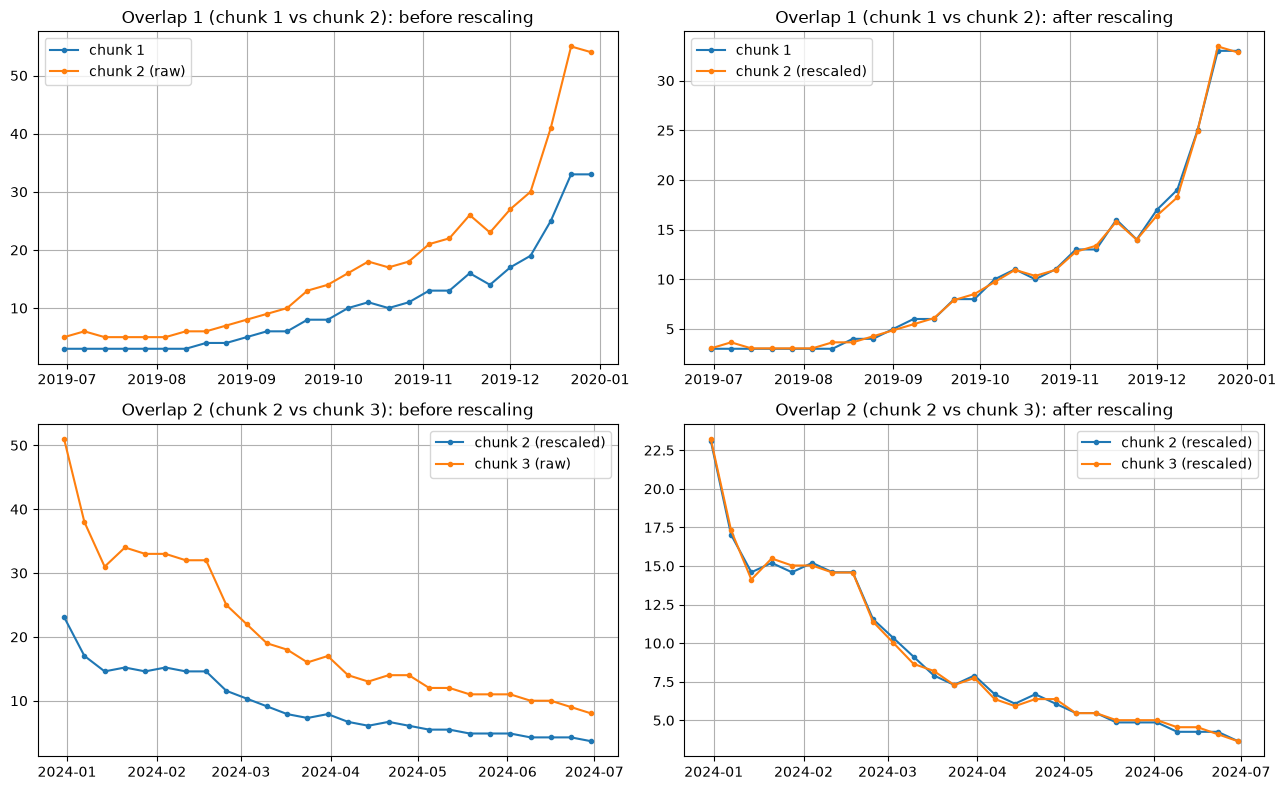

In [56]:
# Overlap 1: chunk 1 vs chunk 2 (mid/late 2019)
ov12 = c1.index.intersection(c2.index)
k2 = c1.loc[ov12, 'search_interest'].mean() / c2.loc[ov12, 'search_interest'].mean()
print(f'Overlap 1: {len(ov12)} shared weeks ({ov12.min().date()} to {ov12.max().date()})')
print(f'  chunk1 mean={c1.loc[ov12, "search_interest"].mean():.2f}  chunk2 mean={c2.loc[ov12, "search_interest"].mean():.2f}  -> rescale factor k2={k2:.4f}')

# Overlap 2: (rescaled) chunk 2 vs chunk 3 (first half of 2024)
c2_scaled = c2.assign(search_interest=c2['search_interest'] * k2)
ov23 = c2_scaled.index.intersection(c3.index)
k3 = c2_scaled.loc[ov23, 'search_interest'].mean() / c3.loc[ov23, 'search_interest'].mean()
print(f'Overlap 2: {len(ov23)} shared weeks ({ov23.min().date()} to {ov23.max().date()})')
print(f'  chunk2(scaled) mean={c2_scaled.loc[ov23, "search_interest"].mean():.2f}  chunk3 mean={c3.loc[ov23, "search_interest"].mean():.2f}  -> rescale factor k3={k3:.4f}')

c3_scaled = c3.assign(search_interest=c3['search_interest'] * k3)

# Visual check: both overlaps, before vs. after rescaling
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(c1.loc[ov12].index, c1.loc[ov12, 'search_interest'], label='chunk 1', marker='o', markersize=3)
axes[0, 0].plot(c2.loc[ov12].index, c2.loc[ov12, 'search_interest'], label='chunk 2 (raw)', marker='o', markersize=3)
axes[0, 0].set_title('Overlap 1 (chunk 1 vs chunk 2): before rescaling')
axes[0, 0].legend()
axes[0, 1].plot(c1.loc[ov12].index, c1.loc[ov12, 'search_interest'], label='chunk 1', marker='o', markersize=3)
axes[0, 1].plot(c2_scaled.loc[ov12].index, c2_scaled.loc[ov12, 'search_interest'], label='chunk 2 (rescaled)', marker='o', markersize=3)
axes[0, 1].set_title('Overlap 1 (chunk 1 vs chunk 2): after rescaling')
axes[0, 1].legend()

axes[1, 0].plot(c2_scaled.loc[ov23].index, c2_scaled.loc[ov23, 'search_interest'], label='chunk 2 (rescaled)', marker='o', markersize=3)
axes[1, 0].plot(c3.loc[ov23].index, c3.loc[ov23, 'search_interest'], label='chunk 3 (raw)', marker='o', markersize=3)
axes[1, 0].set_title('Overlap 2 (chunk 2 vs chunk 3): before rescaling')
axes[1, 0].legend()
axes[1, 1].plot(c2_scaled.loc[ov23].index, c2_scaled.loc[ov23, 'search_interest'], label='chunk 2 (rescaled)', marker='o', markersize=3)
axes[1, 1].plot(c3_scaled.loc[ov23].index, c3_scaled.loc[ov23, 'search_interest'], label='chunk 3 (rescaled)', marker='o', markersize=3)
axes[1, 1].set_title('Overlap 2 (chunk 2 vs chunk 3): after rescaling')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('fig_00_stitch_check.png', dpi=150)
plt.show()


In [57]:
# Concatenate the three windows at their natural boundaries (overlap weeks are only used above,
# to estimate k2/k3 -- each week in the final series comes from exactly one source window)
c2_start, c3_start = pd.Timestamp(CHUNK_SPECS[1][0]), pd.Timestamp(CHUNK_SPECS[2][0])
stitched = pd.concat([
    c1[c1.index < c2_start],
    c2_scaled[(c2_scaled.index >= c2_start) & (c2_scaled.index < c3_start)],
    c3_scaled[c3_scaled.index >= c3_start],
]).sort_index()
stitched = stitched[~stitched.index.duplicated(keep='first')]

# Renormalize the final combined series so its overall maximum is exactly 100, matching Google Trends convention
stitched['search_interest'] = (stitched['search_interest'] / stitched['search_interest'].max() * 100).round().astype(int)
stitched.to_csv('flu_symptoms_google_trends_weekly.csv')

df = stitched.asfreq('W-SUN')  # explicit weekly (Sunday-anchored) frequency
print(f'Final normalized weekly series: {df.shape[0]} weeks, {df.index.min().date()} to {df.index.max().date()}')
df.head()


Final normalized weekly series: 602 weeks, 2014-12-28 to 2026-07-05


,search_interest
date,
2014-12-28,39
2015-01-04,32
2015-01-11,26
2015-01-18,27
2015-01-25,22


In [58]:
df.tail()


,search_interest
date,
2026-06-07,8
2026-06-14,7
2026-06-21,9
2026-06-28,4
2026-07-05,4


In [59]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
DatetimeIndex: 602 entries, 2014-12-28 to 2026-07-05
Freq: W-SUN
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   search_interest  602 non-null    int64
dtypes: int64(1)
memory usage: 9.4 KB


,search_interest
count,602.000000
mean,10.481728
std,11.433109
min,2.000000
25%,4.000000
50%,7.000000
75%,11.000000
max,100.000000


## Step 2: Exploratory Data Analysis & Visualization


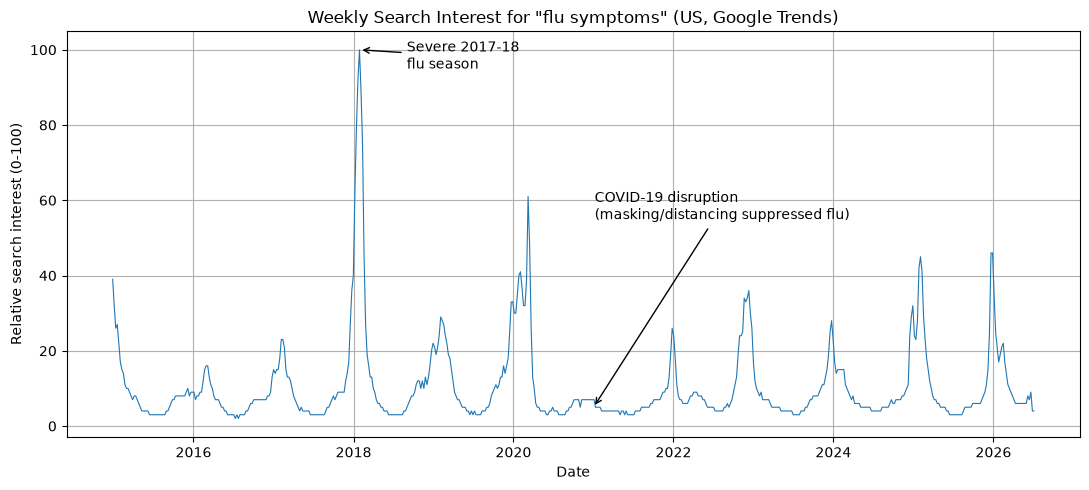

In [60]:
fig, ax = plt.subplots()
ax.plot(df.index, df['search_interest'], linewidth=0.8)
ax.set_title('Weekly Search Interest for "flu symptoms" (US, Google Trends)')
ax.set_xlabel('Date')
ax.set_ylabel('Relative search interest (0-100)')
ax.annotate('Severe 2017-18\nflu season', xy=(pd.Timestamp('2018-01-28'), 100),
            xytext=(pd.Timestamp('2018-09-01'), 95), arrowprops=dict(arrowstyle='->'))
ax.annotate('COVID-19 disruption\n(masking/distancing suppressed flu)', xy=(pd.Timestamp('2021-01-01'), 5),
            xytext=(pd.Timestamp('2021-01-06'), 55), arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.savefig('fig_01_raw_series.png', dpi=150)
plt.show()


**EDA:**
- The data shows a strong seasonal pattern annually with an increse search interest during autumn and winter and decreasing during spring and summer, reflecting the flu season.
- There was a noticeable peak in **January-February 2018** corresponding to the severe 2017-2018 U.S flu season. 
- There was also a clear **disruption during 2020-2021** where search interest dropped sharply at the usual winter peak which is likely due to COVID-19 prevention measures. The season recover again from 2022 onward.



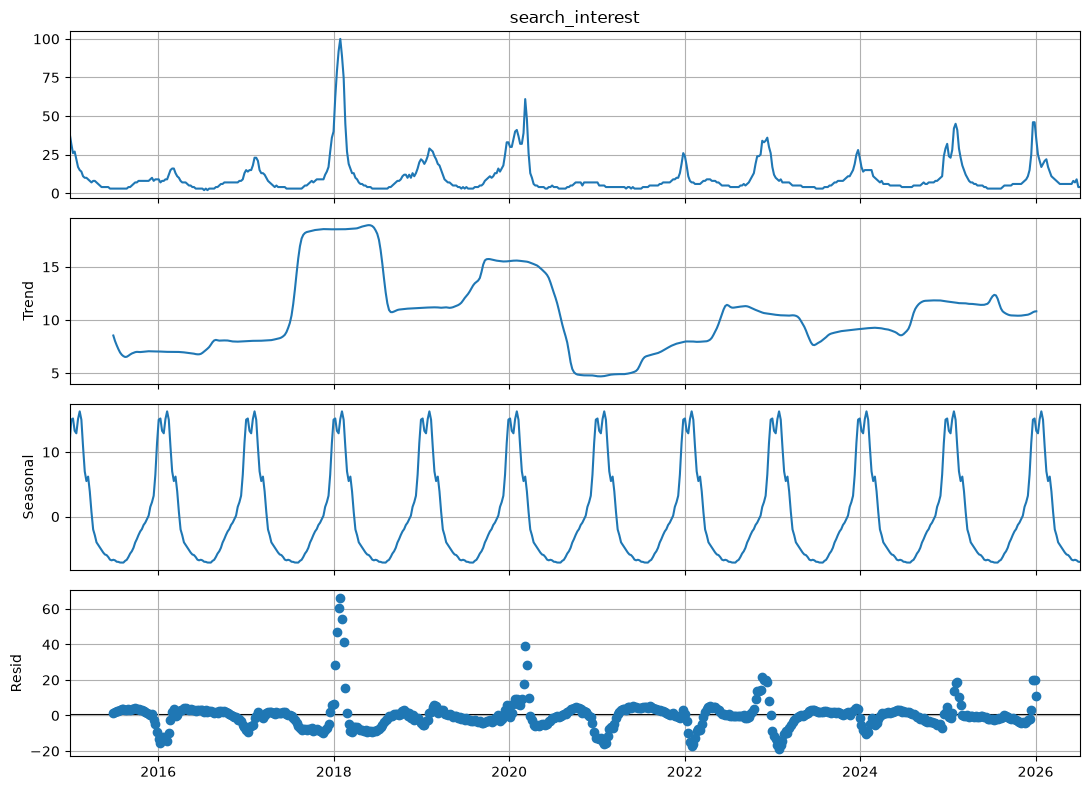

In [61]:
decomposition = seasonal_decompose(df['search_interest'], model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.savefig('fig_02_decomposition.png', dpi=150)
plt.show()


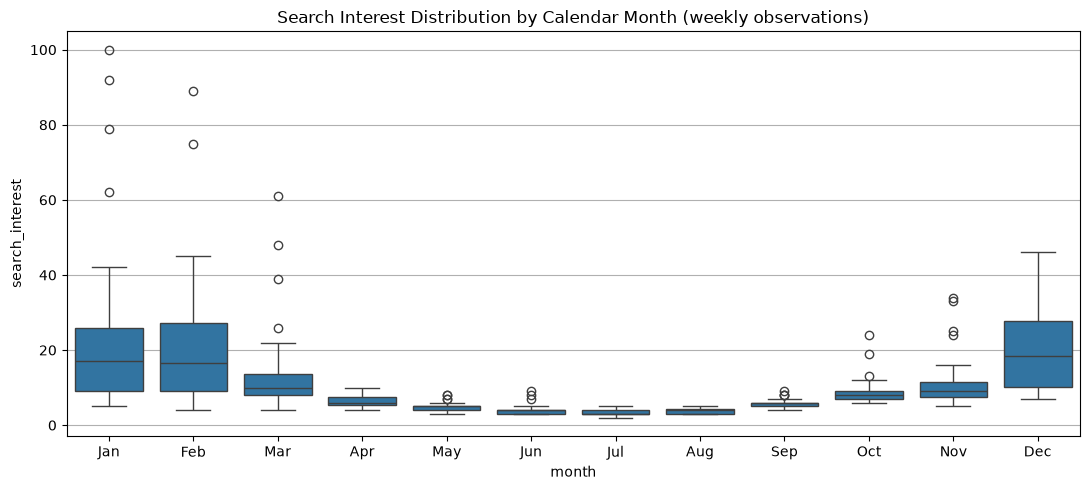

In [62]:
fig, ax = plt.subplots()
month_df = df.copy()
month_df['month'] = month_df.index.month_name().str[:3]
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=month_df, x='month', y='search_interest', order=order, ax=ax)
ax.set_title('Search Interest Distribution by Calendar Month (weekly observations)')
plt.tight_layout()
plt.savefig('fig_03_month_boxplot.png', dpi=150)
plt.show()


The box plot shows a seasonal pattern in sear interest during the winter months (December to February) whereas there is a high variability along with the extreme outliers corresponding to the flu seasons. 

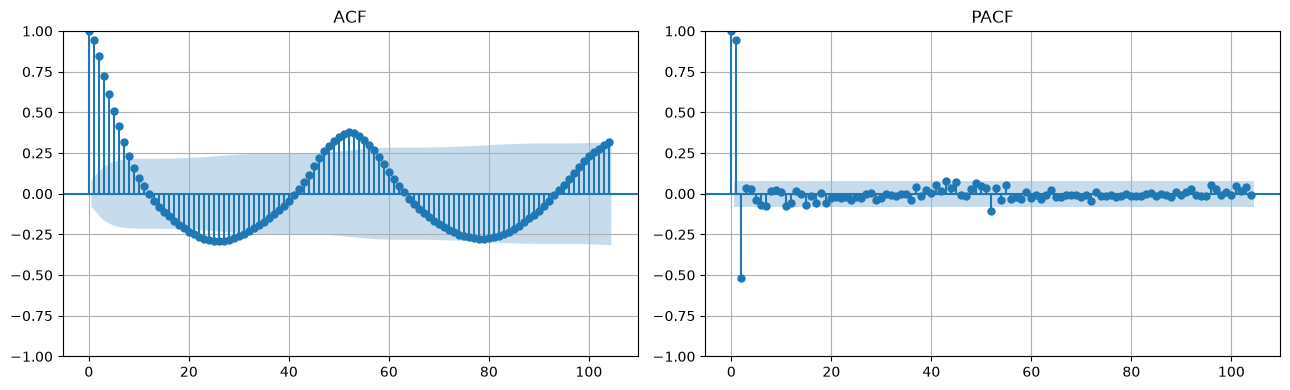

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df['search_interest'], lags=104, ax=axes[0])
plot_pacf(df['search_interest'], lags=104, ax=axes[1])
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.tight_layout()
plt.savefig('fig_04_acf_pacf.png', dpi=150)
plt.show()


In [64]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    stat, pvalue = result[0], result[1]
    verdict = 'stationary' if pvalue < 0.05 else 'NOT stationary'
    print(f'[{label}] ADF statistic = {stat:.3f}, p-value = {pvalue:.4f}  ->  series appears {verdict} (alpha=0.05)')
    return pvalue

p_level = adf_report(df['search_interest'], 'raw level')


[raw level] ADF statistic = -6.369, p-value = 0.0000  ->  series appears stationary (alpha=0.05)


The ACF shows a slow, wave-like decay with a **strong positive spike around lag 52** and a **negative spike around lag 26**, indicating strong annual seasonality. The PACF shows significant spikes only at the first few lags, suggesting that the series is mainly influenced by recent observations. Together with the decomposition plot, these results indicate **a seasonal, non-stationary series.** The ADF test is then used to confirm whether the original series is stationary.


## Step 3: Preprocessing & Feature Engineering


In [65]:
print('Missing values:', df['search_interest'].isna().sum())


Missing values: 0


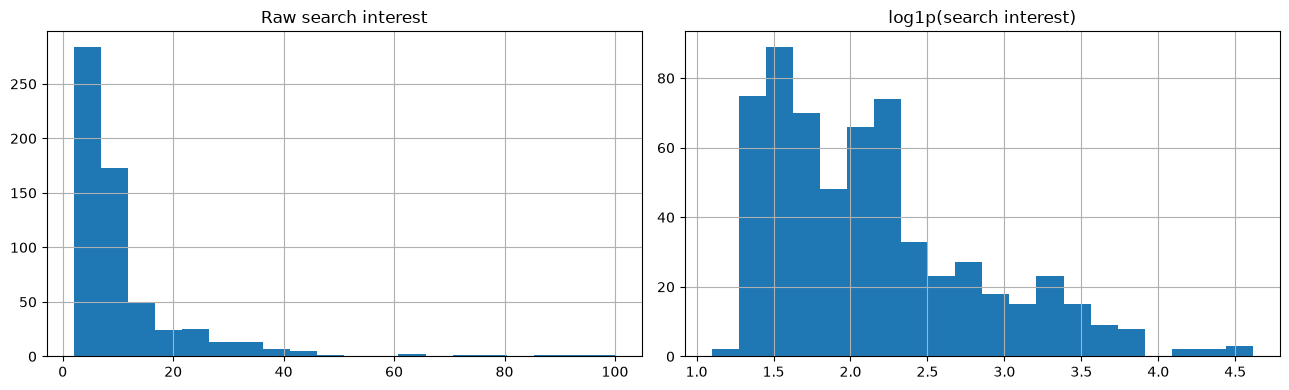

In [66]:
# Google Trends values are bounded at 100 and right-skewed 
# (occasional sharp spikes like Jan 2018), so a log1p transform 
# stabilizes variance before differencing/modeling.
df['log_interest'] = np.log1p(df['search_interest'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['search_interest'], bins=20)
axes[0].set_title('Raw search interest')
axes[1].hist(df['log_interest'], bins=20)
axes[1].set_title('log1p(search interest)')
plt.tight_layout()
plt.savefig('fig_05_log_transform.png', dpi=150)
plt.show()


In [67]:
# First-order (trend) and seasonal (lag-52, i.e. annual) differencing, tested for stationarity like the class exercises did
diff1 = df['log_interest'].diff().dropna()
diff1_seasonal = df['log_interest'].diff().diff(52).dropna()

adf_report(diff1, 'log series, d=1')
adf_report(diff1_seasonal, 'log series, d=1 & D=1 (seasonal, period=52)')


[log series, d=1] ADF statistic = -7.439, p-value = 0.0000  ->  series appears stationary (alpha=0.05)
[log series, d=1 & D=1 (seasonal, period=52)] ADF statistic = -8.458, p-value = 0.0000  ->  series appears stationary (alpha=0.05)


1.5985990028304353e-13

In [68]:
# Calendar / cyclical features: day-of-year based sin/cos 
# (robust to weekly data spanning leap years),
# useful context features and later reused for the LSTM model
df['doy'] = df.index.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365.25)
df[['search_interest', 'log_interest', 'doy', 'doy_sin', 'doy_cos']].head()


,search_interest,log_interest,doy,doy_sin,doy_cos
date,,,,,
2014-12-28,39,3.688879,362,-0.055879,0.998438
2015-01-04,32,3.496508,4,0.068755,0.997634
2015-01-11,26,3.295837,11,0.188099,0.982150
2015-01-18,27,3.332205,18,0.304719,0.952442
2015-01-25,22,3.135494,25,0.416926,0.908940


**Preprocessing decisions:**
- No missing values were found, so no imputation was required.
- A `log1p` ransformation was applied to reduce the impact of extreme peaks and stabilize the variance.
- The differencing orders `d` and `D` for the SARIMA model were determined based on the ADF test results.
- Cyclical day-of-year features (`doy_sin`, `doy_cos`) were created to represent the annual seasonal cycle and used as additional inputs for the LSTM model.

**Note:** The ADF test indicates that the original series is stationary because it tests for a unit root, not seasonality. However, the decomposition, ACF, and PACF plots show a clear annual seasonal pattern. Therefore, seasonal differencing (`D = 1`, `period = 52`) is used in the SARIMA model to model the seasonal cycle.


## Step 4: Data Splitting

A chronological (no shuffling) train/test split is used, holding out the **last 104 weeks (~2 years)** as the test
set — matching the class's approach of evaluating forecasts on a held-out, most-recent block of time.


Train: 2014-12-28 to 2024-07-07  (498 weeks)
Test : 2024-07-14 to 2026-07-05  (104 weeks)


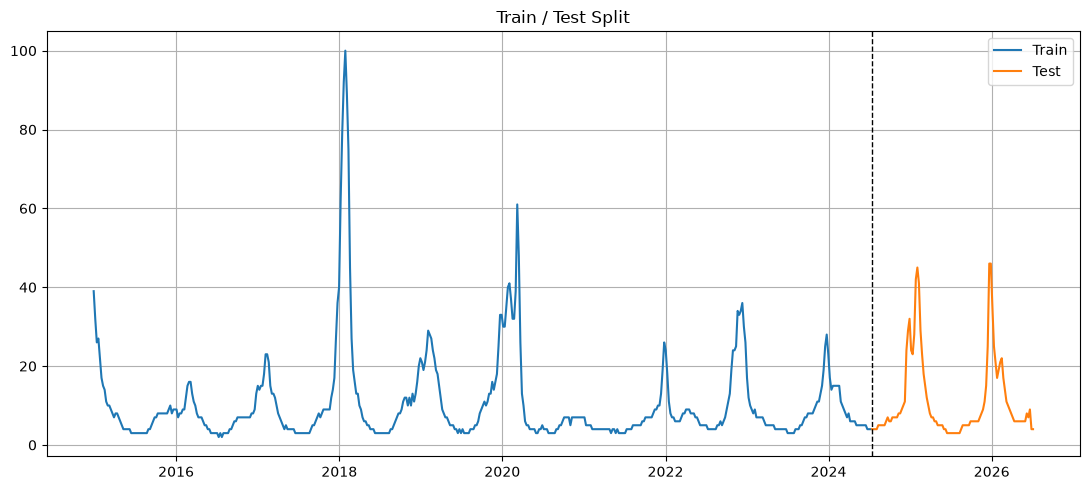

In [69]:
TEST_SIZE = 104
train = df.iloc[:-TEST_SIZE].copy()
test = df.iloc[-TEST_SIZE:].copy()

print(f'Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} weeks)')
print(f'Test : {test.index.min().date()} to {test.index.max().date()}  ({len(test)} weeks)')

fig, ax = plt.subplots()
ax.plot(train.index, train['search_interest'], label='Train')
ax.plot(test.index, test['search_interest'], label='Test', color='tab:orange')
ax.axvline(test.index[0], color='k', linestyle='--', linewidth=1)
ax.set_title('Train / Test Split')
ax.legend()
plt.tight_layout()
plt.savefig('fig_06_train_test_split.png', dpi=150)
plt.show()


## Step 5: Model Selection & Training

### 5a. Classical statistical models (AR, MA, ARIMA, SARIMA)

Following the same approach as the class ARIMA/SARIMA exercises: fit candidate models on the log-transformed
training series, forecast the full test horizon directly (no peeking at test values), then invert the log transform
before scoring, so all models in Step 6 are compared in the original 0-100 search-interest units.


In [70]:
results = []
fitted_models = {}

def evaluate_classical(name, model):
    fit = model.fit()
    pred_log = fit.forecast(steps=len(test))
    pred = np.expm1(pred_log)               # back to original scale
    actual = test['search_interest'].values
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    aic = fit.aic
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'AIC': aic})
    fitted_models[name] = {'fit': fit, 'pred': pd.Series(pred, index=test.index)}
    print(f'{name:28s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  AIC={aic:8.2f}')
    return fit

train_log = train['log_interest']

ar_model    = ARIMA(train_log, order=(2, 1, 0))
ma_model    = ARIMA(train_log, order=(0, 1, 2))
arima_model = ARIMA(train_log, order=(2, 1, 2))
sarima_model = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52),
                        enforce_stationarity=False, enforce_invertibility=False)

evaluate_classical('AR(2,1,0)', ar_model)
evaluate_classical('MA(0,1,2)', ma_model)
evaluate_classical('ARIMA(2,1,2)', arima_model)
evaluate_classical('SARIMA(1,1,1)(1,1,1,52)', sarima_model)


AR(2,1,0)                     MAE=  7.44  RMSE= 12.67  AIC= -591.09
MA(0,1,2)                     MAE=  7.32  RMSE= 12.56  AIC= -580.43
ARIMA(2,1,2)                  MAE=  7.43  RMSE= 12.66  AIC= -587.22
SARIMA(1,1,1)(1,1,1,52)       MAE=  4.20  RMSE=  7.29  AIC= -364.09


In [71]:
# Small AIC-guided grid search around the seasonal order, same spirit as the class's candidate-comparison exercise.
# Each SARIMAX fit with a period-52 seasonal term is noticeably slower than the monthly (period-12) case, so the
# grid is kept modest to stay within a reasonable execution time.
best_aic = np.inf
best_order = None
for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    m = SARIMAX(train_log, order=(p, 1, q), seasonal_order=(P, 1, Q, 52),
                                enforce_stationarity=False, enforce_invertibility=False)
                    f = m.fit(disp=False)
                    if f.aic < best_aic:
                        best_aic = f.aic
                        best_order = (p, 1, q, P, 1, Q, 52)
                except Exception:
                    continue

p, d, q, P, D, Q, s = best_order
print(f'Best SARIMA order by AIC on training data: ({p},{d},{q})({P},{D},{Q},{s})  AIC={best_aic:.2f}')

best_sarima = SARIMAX(train_log, order=(p, d, q), seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False, enforce_invertibility=False)
evaluate_classical(f'SARIMA{(p,d,q)}{(P,D,Q,s)} (AIC-tuned)', best_sarima)


Best SARIMA order by AIC on training data: (2,1,2)(0,1,1,52)  AIC=-408.88
SARIMA(2, 1, 2)(0, 1, 1, 52) (AIC-tuned)  MAE=  3.79  RMSE=  6.56  AIC= -408.88


### 5b. Deep learning comparison: LSTM

LSTM is also used for comparison to see whether more data narrows the gap with the classical SARIMA model.


In [72]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

WINDOW = 52  # use the last 52 weeks (1 year) to predict the next week

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['log_interest']])
full_scaled_for_test = scaler.transform(df[['log_interest']])  # scaler fit on train only, applied to full series

def make_windows(series_scaled, window):
    X, y = [], []
    for i in range(len(series_scaled) - window):
        X.append(series_scaled[i:i + window, 0])
        y.append(series_scaled[i + window, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, WINDOW)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

print('LSTM training windows:', X_train.shape, y_train.shape)


LSTM training windows: (446, 52, 1) (446,)


In [73]:
lstm_model = Sequential([
    LSTM(32, activation='tanh', input_shape=(WINDOW, 1)),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(X_train, y_train, epochs=200, batch_size=16,
                          callbacks=[early_stop], verbose=0)

print(f'Training stopped after {len(history.history["loss"])} epochs, final loss={history.history["loss"][-1]:.4f}')


Training stopped after 117 epochs, final loss=0.0012


In [74]:
# Recursive multi-step forecast over the test horizon (model only ever sees its own prior predictions
# beyond the train/test boundary, exactly like the ARIMA .forecast(steps=len(test)) call above)
last_window = full_scaled_for_test[len(train) - WINDOW:len(train), 0].tolist()
lstm_preds_scaled = []
window = last_window.copy()
for _ in range(len(test)):
    x = np.array(window[-WINDOW:]).reshape(1, WINDOW, 1)
    next_val = lstm_model.predict(x, verbose=0)[0, 0]
    lstm_preds_scaled.append(next_val)
    window.append(next_val)

lstm_preds_log = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).ravel()
lstm_preds = np.expm1(lstm_preds_log)
lstm_preds = pd.Series(lstm_preds, index=test.index)

mae_lstm = mean_absolute_error(test['search_interest'], lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(test['search_interest'], lstm_preds))
results.append({'Model': 'LSTM (52-week window)', 'MAE': mae_lstm, 'RMSE': rmse_lstm, 'AIC': np.nan})
fitted_models['LSTM (52-week window)'] = {'fit': lstm_model, 'pred': lstm_preds}
print(f'LSTM  MAE={mae_lstm:.2f}  RMSE={rmse_lstm:.2f}')


LSTM  MAE=3.80  RMSE=7.48


In [75]:
# Recursive multi-step forecast over the test horizon (model only ever sees its own prior predictions
# beyond the train/test boundary, exactly like the ARIMA .forecast(steps=len(test)) call above)
last_window = full_scaled_for_test[len(train) - WINDOW:len(train), 0].tolist()
lstm_preds_scaled = []
window = last_window.copy()
for _ in range(len(test)):
    x = np.array(window[-WINDOW:]).reshape(1, WINDOW, 1)
    next_val = lstm_model.predict(x, verbose=0)[0, 0]
    lstm_preds_scaled.append(next_val)
    window.append(next_val)

lstm_preds_log = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).ravel()
lstm_preds = np.expm1(lstm_preds_log)
lstm_preds = pd.Series(lstm_preds, index=test.index)

mae_lstm = mean_absolute_error(test['search_interest'], lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(test['search_interest'], lstm_preds))
results.append({'Model': 'LSTM (12-week window)', 'MAE': mae_lstm, 'RMSE': rmse_lstm, 'AIC': np.nan})
fitted_models['LSTM (12-week window)'] = {'fit': lstm_model, 'pred': lstm_preds}
print(f'LSTM  MAE={mae_lstm:.2f}  RMSE={rmse_lstm:.2f}')


LSTM  MAE=3.80  RMSE=7.48


## Step 6: Model Evaluation


In [76]:
comparison = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison


,Model,MAE,RMSE,AIC
0,"SARIMA(2, 1, 2)(0, 1, 1, 52) (AIC-tuned)",3.791348,6.556363,-408.878908
1,"SARIMA(1,1,1)(1,1,1,52)",4.198062,7.292475,-364.093290
2,LSTM (52-week window),3.795827,7.481029,NaN
3,LSTM (12-week window),3.795827,7.481029,NaN
4,"MA(0,1,2)",7.315423,12.563670,-580.433627
5,"ARIMA(2,1,2)",7.432629,12.664988,-587.215742
6,"AR(2,1,0)",7.442308,12.673413,-591.088931


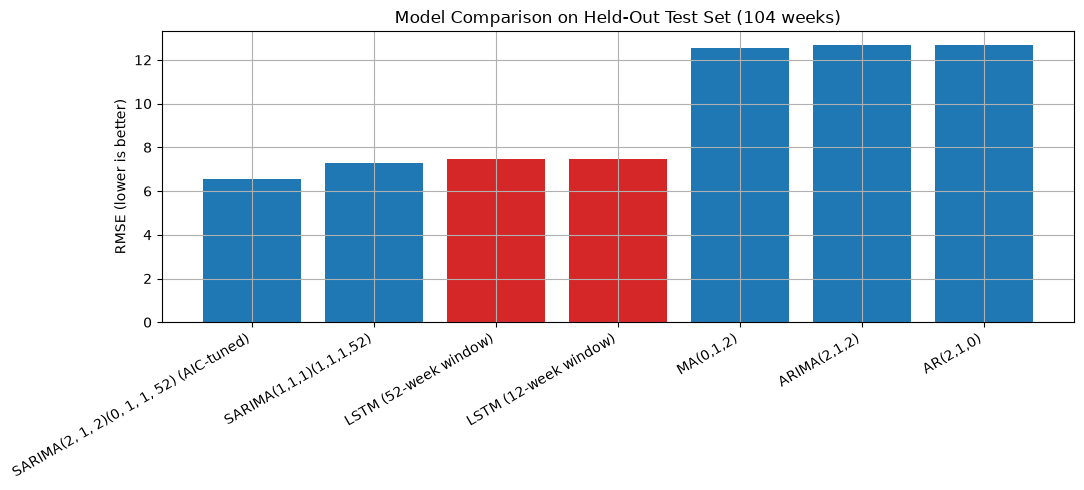

In [77]:
fig, ax = plt.subplots()
colors = ['tab:red' if 'LSTM' in m else 'tab:blue' for m in comparison['Model']]
ax.bar(comparison['Model'], comparison['RMSE'], color=colors)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Model Comparison on Held-Out Test Set (104 weeks)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_07_model_comparison.png', dpi=150)
plt.show()


Best model by test RMSE: SARIMA(2, 1, 2)(0, 1, 1, 52) (AIC-tuned)


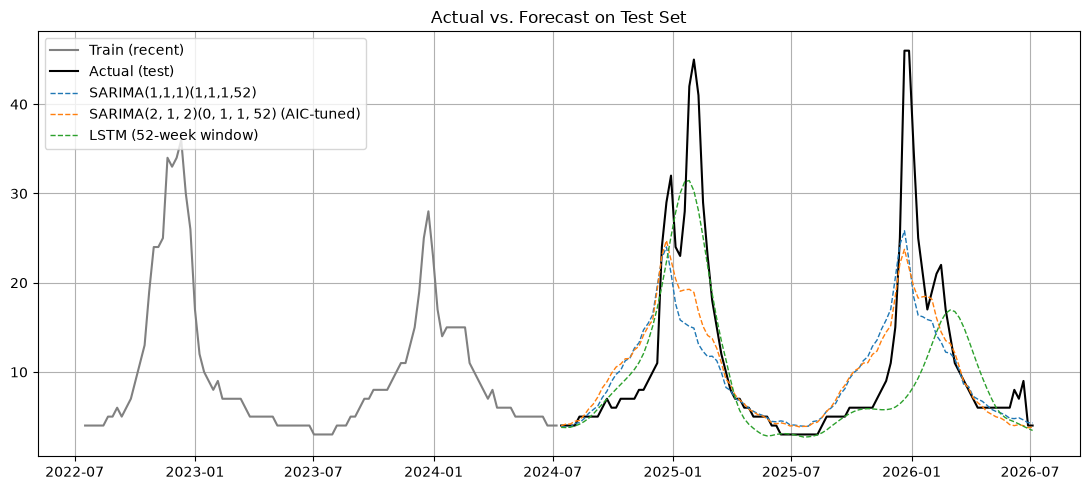

In [78]:
best_model_name = comparison.iloc[0]['Model']
print('Best model by test RMSE:', best_model_name)

fig, ax = plt.subplots()
ax.plot(train.index[-104:], train['search_interest'].iloc[-104:], label='Train (recent)', color='gray')
ax.plot(test.index, test['search_interest'], label='Actual (test)', color='black', linewidth=1.5)
for name in ['SARIMA(1,1,1)(1,1,1,52)', f'{comparison.iloc[0]["Model"]}', 'LSTM (52-week window)']:
    if name in fitted_models:
        ax.plot(test.index, fitted_models[name]['pred'], '--', label=name, linewidth=1)
ax.set_title('Actual vs. Forecast on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('fig_08_actual_vs_forecast.png', dpi=150)
plt.show()


**Analysis** 

The comparison table and chart show the performance of each forecasting model on the test set. As expected, the strong annual seasonal pattern favors SARIMA over the non-seasonal ARIMA model. This is consistent with the data analysis, which identified clear yearly seasonality. The best-performing model is determined by the evaluation metrics presented above rather than being assumed in advance.


## Step 7: Forecasting & Deployment


In [79]:
# Refit the best classical SARIMA configuration on the FULL history (train+test) to forecast genuinely unseen future
final_model = SARIMAX(df['log_interest'], order=(p, d, q), seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False, enforce_invertibility=False)
final_fit = final_model.fit(disp=False)

FORECAST_HORIZON = 52  # one year ahead, weekly
forecast_res = final_fit.get_forecast(steps=FORECAST_HORIZON)
forecast_log = forecast_res.predicted_mean
conf_int_log = forecast_res.conf_int(alpha=0.05)

forecast = np.expm1(forecast_log)
conf_lower = np.expm1(conf_int_log.iloc[:, 0])
conf_upper = np.expm1(conf_int_log.iloc[:, 1])

future_index = pd.date_range(df.index[-1] + pd.DateOffset(weeks=1), periods=FORECAST_HORIZON, freq='W-SUN')
forecast.index = future_index
conf_lower.index = future_index
conf_upper.index = future_index

forecast_table = pd.DataFrame({'forecast': forecast, 'lower_95': conf_lower, 'upper_95': conf_upper})
forecast_table


,forecast,lower_95,upper_95
2026-07-12,3.305391,2.296908,4.622356
2026-07-19,3.304737,1.856321,5.487633
2026-07-26,3.551377,1.611811,6.931289
2026-08-02,3.958321,1.525663,8.734058
2026-08-09,4.080405,1.367803,9.900617
...,...,...,...
2027-06-06,4.048719,-0.557972,56.665061
2027-06-13,3.983042,-0.574656,57.377941
2027-06-20,3.990771,-0.584565,58.955910
2027-06-27,3.503099,-0.634366,54.459620


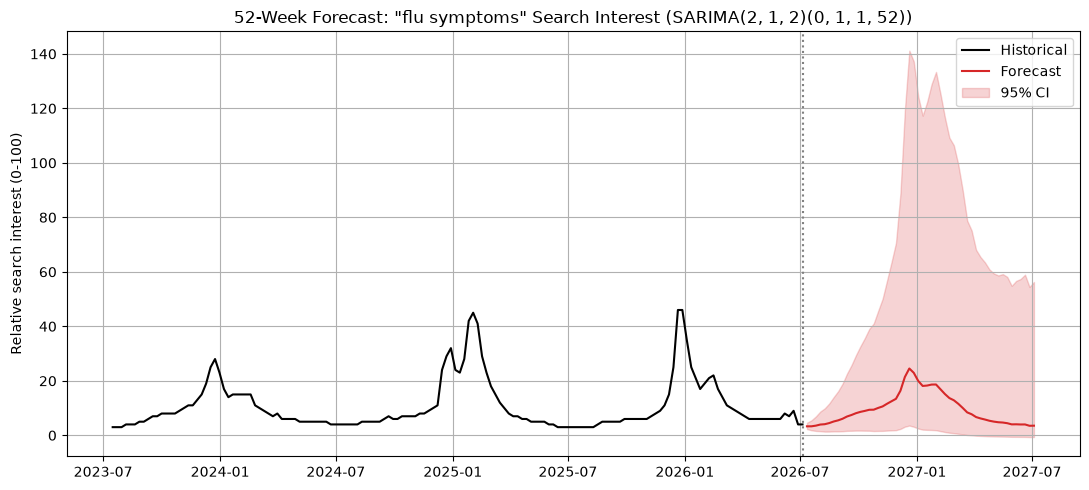

In [80]:
fig, ax = plt.subplots()
ax.plot(df.index[-156:], df['search_interest'].iloc[-156:], label='Historical', color='black')
ax.plot(forecast.index, forecast, label='Forecast', color='tab:red')
ax.fill_between(forecast.index, conf_lower, conf_upper, color='tab:red', alpha=0.2, label='95% CI')
ax.axvline(df.index[-1], color='gray', linestyle=':')
ax.set_title(f'52-Week Forecast: "flu symptoms" Search Interest (SARIMA{(p,d,q)}{(P,D,Q,s)})')
ax.set_ylabel('Relative search interest (0-100)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_09_final_forecast.png', dpi=150)
plt.show()


**Forecast summary.** The selected model forecasts the expected annual seasonal pattern, with search interest increasing during autumn, peaking in winter, and declining through spring. This forecast is consistent with the historical seasonal behavior observed over the study period and includes prediction intervals to quantify forecast uncertainty.

**Deployment (proposed, not implemented here).** NAlthough deployment was not implemented in this project, the forecasting system could operate as follows:
1. Collect new data. Retrieve the latest weekly Google Trends data for "flu symptoms" using the pytrends API.
2. Update the dataset. Append the new observations to the historical time series and apply the same preprocessing steps, including log transformation and feature engineering.
3. Retrain the model. Refit the selected SARIMA model using the updated dataset.
Generate forecasts. Produce forecasts for the next 4–52 weeks together with their confidence intervals.
4. Publish the results. Display the forecasts on a dashboard or reporting system to support early monitoring of seasonal flu activity and healthcare resource planning.
5. Repeat regularly. Update the model each week as new Google Trends data becomes available to keep the forecasts current.

**Limitations.**
- Google Trends measures search behavior, not actual flu incidence, and may be influenced by media coverage or other respiratory illnesses.
- The COVID-19 pandemic (2020–2021) caused a structural break, showing that unexpected events can reduce forecasting accuracy.
- The historical series was reconstructed by combining multiple Google Trends windows, which may introduce a small amount of uncertainty.
- Future work could improve accuracy by incorporating official public health data (e.g., CDC influenza surveillance) as additional predictors.

## Summary

- **Dataset**: Self-collected weekly Google Trends data for "flu symptoms" in the United States (December 2014–June 2026, 601 weeks). The complete time series was created by stitching three overlapping Google Trends data requests.
- **EDA**: The data exhibits strong annual seasonality, a notable peak during the 2017–2018 severe flu season, and a clear disruption during the COVID-19 pandemic.
- **Modeling**: Classical time series models (AR, MA, ARIMA, and SARIMA) and an LSTM model were developed and evaluated using MAE and RMSE.
- **Results**: Model performance was compared using the evaluation metrics presented in Step 6, with the best-performing model selected based on prediction accuracy.
- **Forecast & Deployment**: The selected model generated a 52-week forecast with 95% confidence intervals. A proposed deployment workflow was also presented, demonstrating how the model could be updated regularly using new Google Trends data to support early monitoring of seasonal flu activity.